In [1]:
# Import libraries
import pandas as pd  # Data manipulation
import numpy as np  # Numerical computations
import matplotlib.pyplot as plt  # Static plots
import seaborn as sns  # Statistical plots
#import missingno as msno  # Missing data visualization

# Configuring Seaborn plot aesthetics
sns.set_theme(style='darkgrid', context='notebook')

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
gender = pd.read_csv("gender_submission.csv")


In [3]:
#
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
#Getting the number of Rows and Columns
print(f"The number of rows and columns in the dataset is  {train.shape[0]} rows and {train.shape[1]} columns")

The number of rows and columns in the dataset is  891 rows and 12 columns


In [5]:
#Summary of the Columns and the Data Types
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
#Converting the Data Types
train['Survived'] = train['Survived'].astype('category')
train['Pclass'] = train['Pclass'].astype('category')
train['Sex'] = train['Sex'].astype('category')
train['Cabin'] = train['Cabin'].astype('category')
train['Embarked'] = train['Embarked'].astype('category')

In [7]:
#Statistical Summary of the Numerical Columns
train.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
#Viewing the Column Names
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [9]:
#Checking for Unique Values
train.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [10]:
#Checking for Duplicates
train.duplicated().sum()

np.int64(0)

<Axes: >

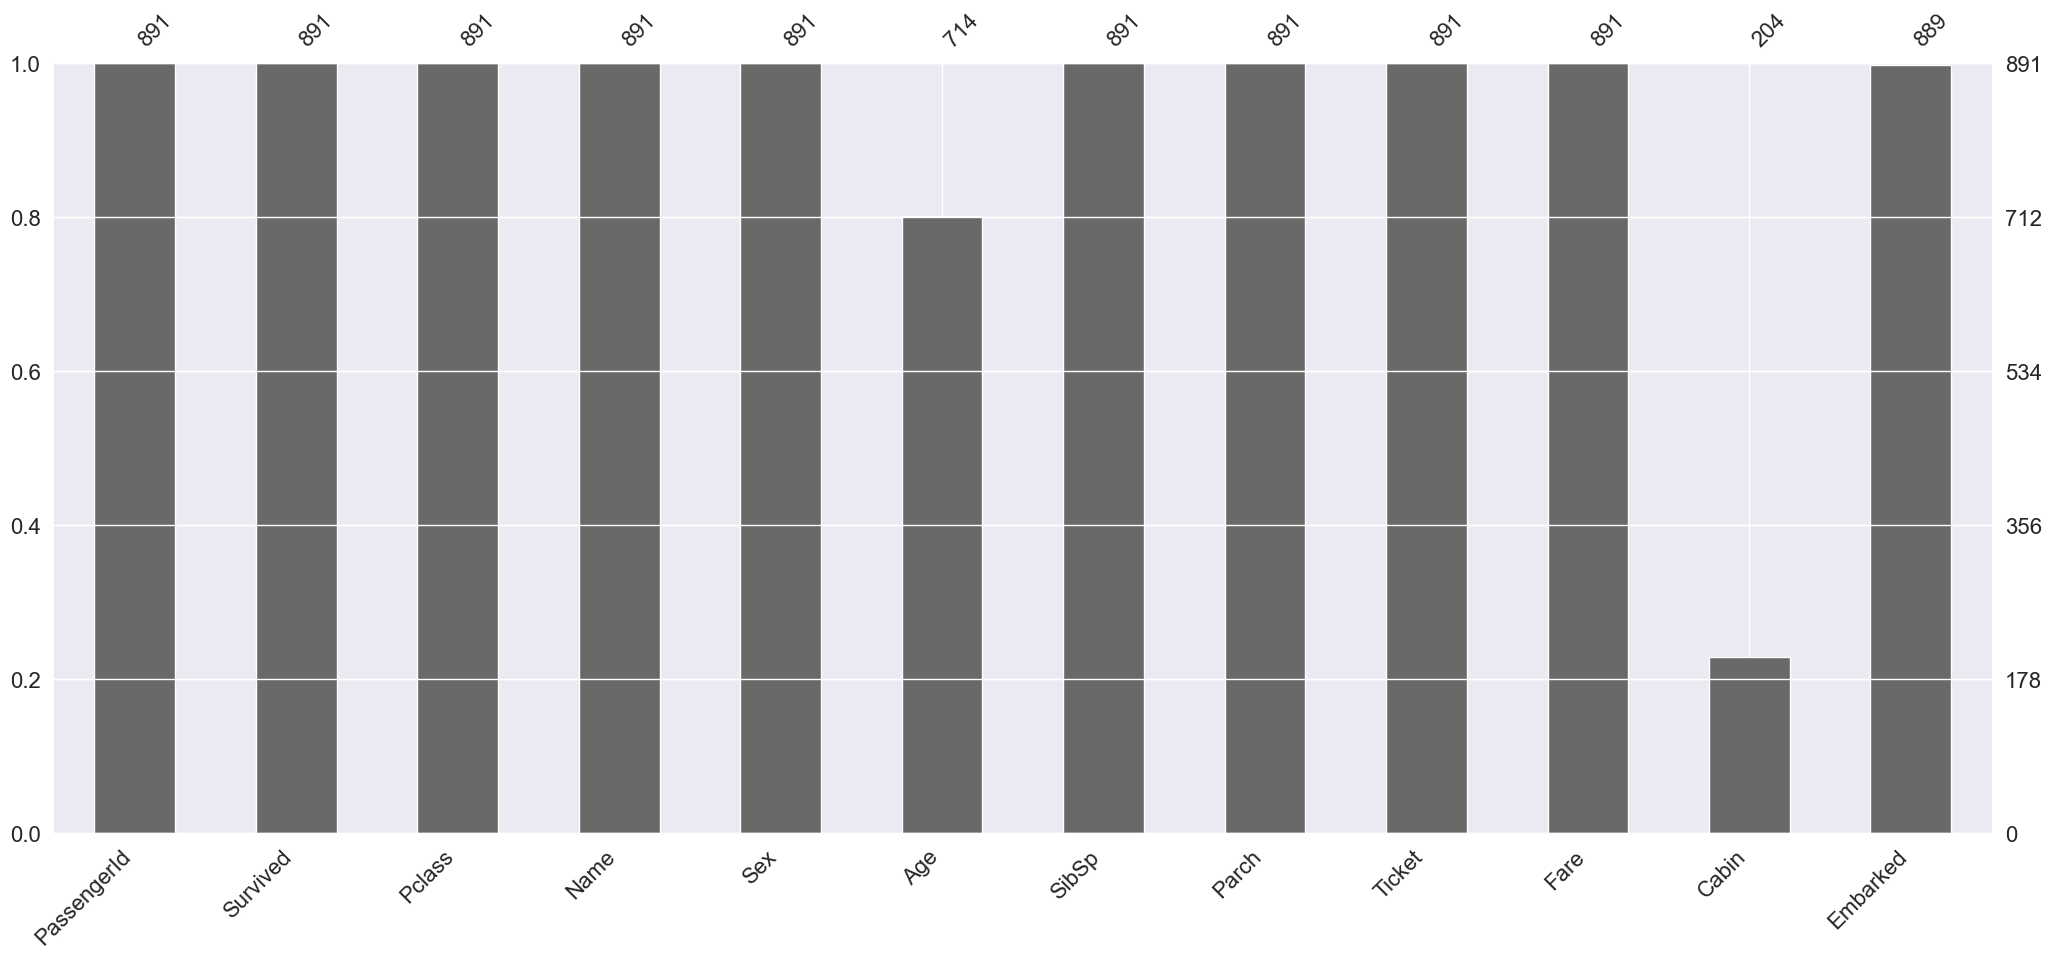

In [11]:
# Visualize missing data using missingno library
import missingno as msno
msno.bar(train)

In [12]:
# Count the number of missing values in each column
missing_values = train.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_values / len(train)) * 100
print(pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage}))

             Missing Values  Percentage
Cabin                   687   77.104377
Age                     177   19.865320
Embarked                  2    0.224467
PassengerId               0    0.000000
Name                      0    0.000000
Pclass                    0    0.000000
Survived                  0    0.000000
Sex                       0    0.000000
Parch                     0    0.000000
SibSp                     0    0.000000
Fare                      0    0.000000
Ticket                    0    0.000000


In [13]:
# Drop a column with too many missing values
train = train.drop(columns=['Cabin'])

In [14]:
# Fill missing values in the 'Age' column with the mean age
train['Age'].fillna(train['Age'].mean(), inplace=True)

# Fill missing values in the 'Fare' column with the median
train['Fare'].fillna(train['Fare'].median(), inplace=True)

# Fill missing values in the 'Embarked' column with the most common value (mode)
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

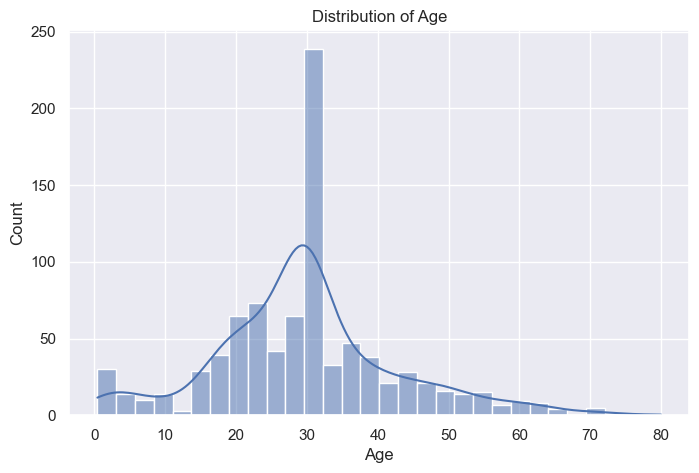

In [15]:
# Histogram for Age
plt.figure(figsize=(8, 5))
sns.histplot(train['Age'].dropna(), bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

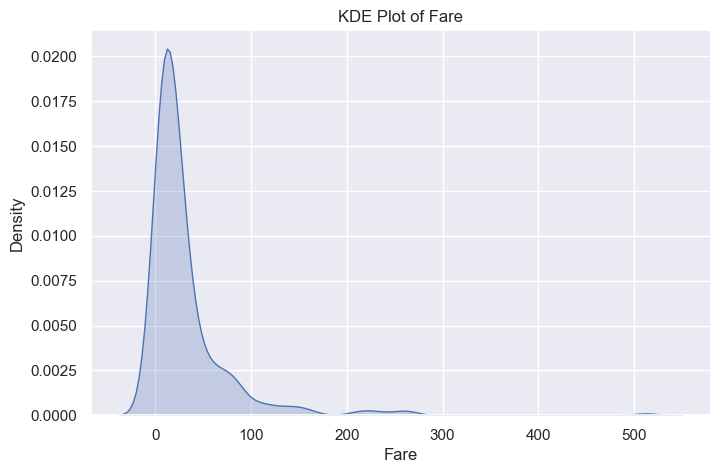

In [16]:
# KDE Plot for Fare
plt.figure(figsize=(8, 5))
sns.kdeplot(train['Fare'], shade=True)
plt.title('KDE Plot of Fare')
plt.xlabel('Fare')
plt.show()

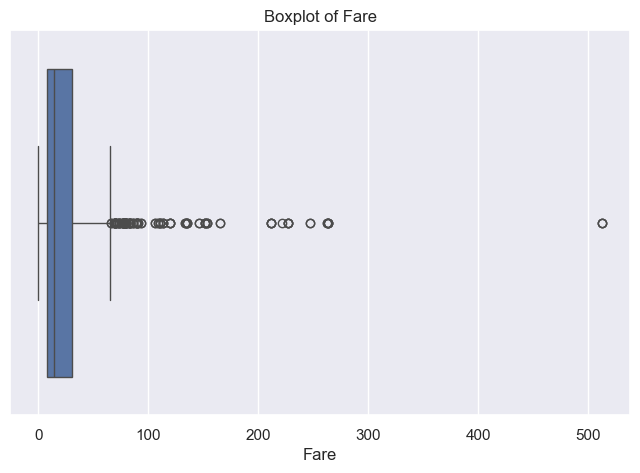

In [17]:
# Boxplot for Fare
plt.figure(figsize=(8, 5))
sns.boxplot(x=train['Fare'])
plt.title('Boxplot of Fare')
plt.show()

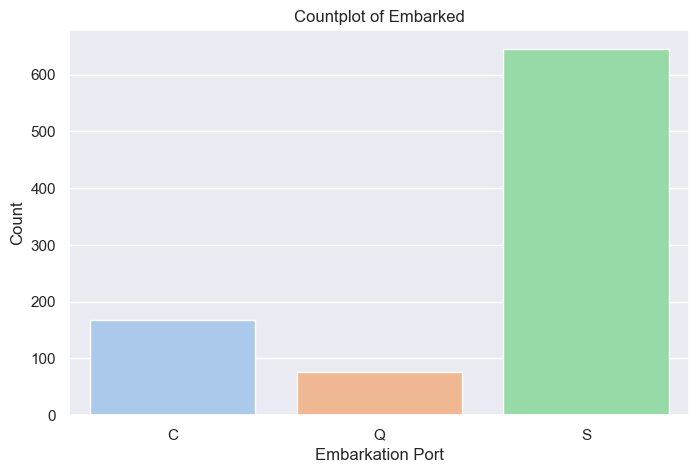

In [18]:
# Countplot for Embarked
plt.figure(figsize=(8, 5))
sns.countplot(x='Embarked', data=train, palette='pastel')
plt.title('Countplot of Embarked')
plt.xlabel('Embarkation Port')
plt.ylabel('Count')
plt.show()

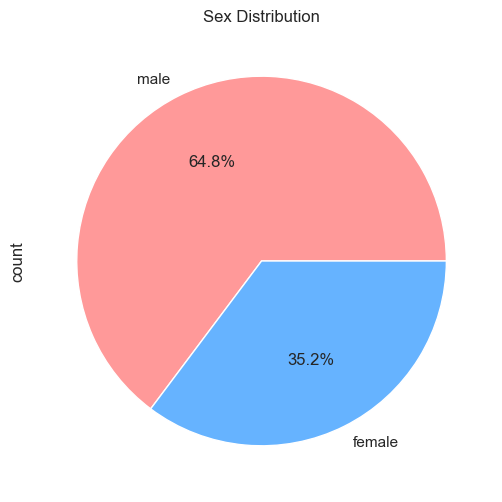

In [19]:
# Pie chart for Sex distribution
train['Sex'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6, 6), colors=['#ff9999', '#66b3ff'])
plt.title('Sex Distribution')
plt.show()

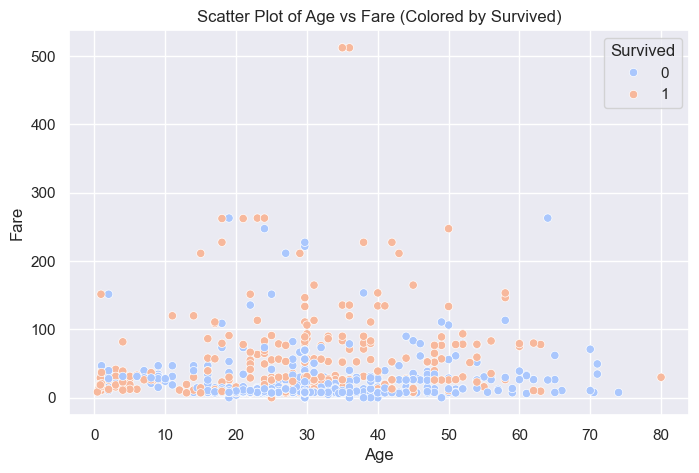

In [20]:
# Scatter plot for Age vs Fare
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Age', y='Fare', data=train, hue='Survived', palette='coolwarm')
plt.title('Scatter Plot of Age vs Fare (Colored by Survived)')
plt.show()


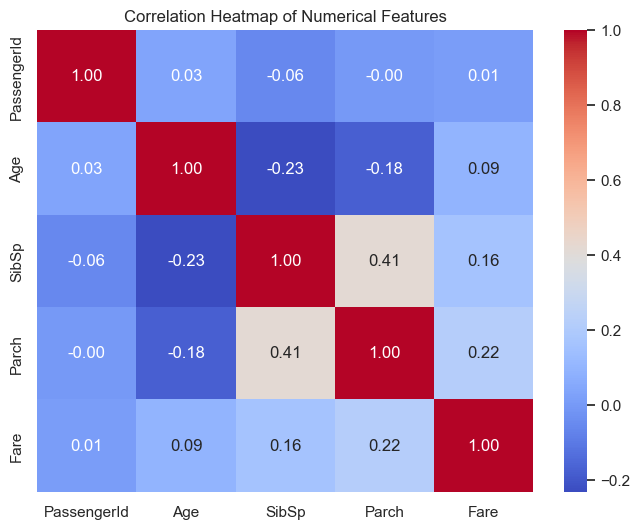

In [21]:
# Correlation heatmap for numerical columns only
plt.figure(figsize=(8, 6))
numerical_columns = train.select_dtypes(include=['int64', 'float64']).columns  # Select only numerical columns
sns.heatmap(train[numerical_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

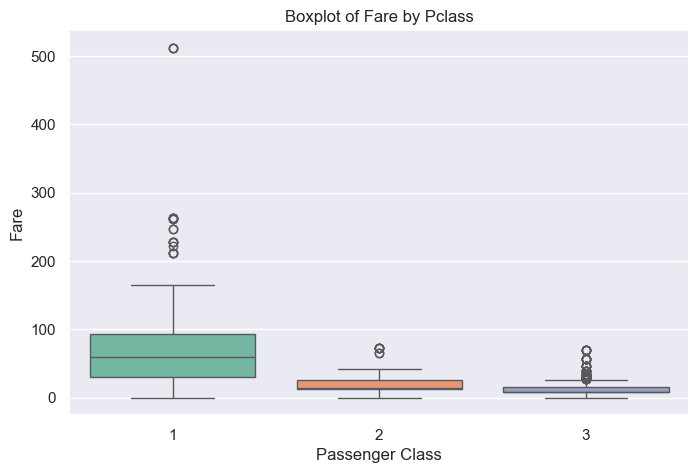

In [22]:
# Boxplot of Fare grouped by Pclass
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Fare', data=train, palette='Set2')
plt.title('Boxplot of Fare by Pclass')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

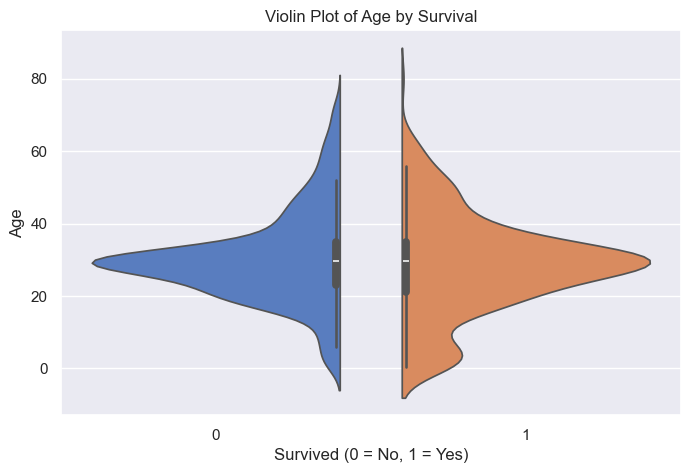

In [23]:
# Violin plot of Age grouped by Survived
plt.figure(figsize=(8, 5))
sns.violinplot(x='Survived', y='Age', data=train, split=True, palette='muted')
plt.title('Violin Plot of Age by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

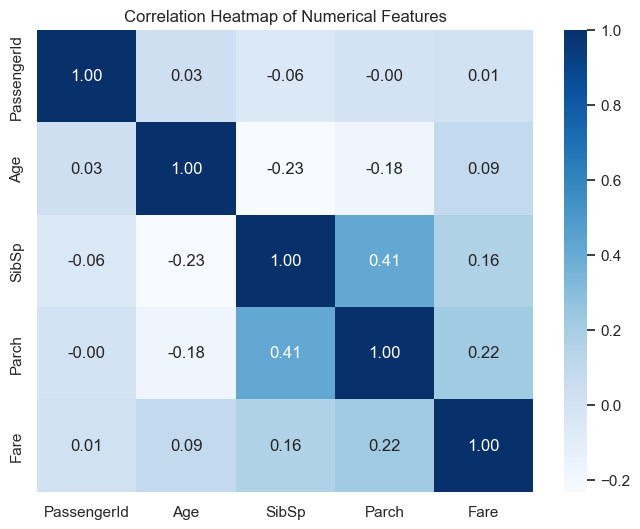

In [24]:
# Heatmap of numerical features only
plt.figure(figsize=(8, 6))
numerical_columns = train.select_dtypes(include=['int64', 'float64']).columns  # Select only numerical columns
sns.heatmap(train[numerical_columns].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()